### Regression Analysis

Regression analysis is a statistical method used to examine the relationship between one dependent variable and one or more independent variables. The goal of regression analysis is to understand how the dependent variable changes when one or more independent variables are altered, and to create a model that can predict the value of the dependent variable based on the values of the independent variables.

1. Define the research question: Identify the dependent variable (the variable you want to predict or explain) and the independent variable(s) (the variables that you think influence the dependent variable).

2. Collect and prepare data: Gather data for the dependent and independent variables. The data should be organized in a tabular format, with each row representing an observation and each column representing a variable. It's essential to clean and pre-process the data to handle missing values, outliers, and other potential issues that may affect the analysis.

3. Visualize the data: Before fitting a linear regression model, it's helpful to create scatter plots to visualize the relationship between the dependent variable and each independent variable. This can help you identify trends, outliers, and any potential issues with the data.

4. Check assumptions: Linear regression has some underlying assumptions, including linearity, independence of errors, homoscedasticity (constant variance of errors), and normality of errors. You can use diagnostic plots and statistical tests to check whether these assumptions hold for your data.

5. Fit the linear regression model: Use statistical software (e.g., R, Python, or Excel) to fit a linear regression model to your data. The model will estimate the regression coefficients (intercept and slope) that minimize the sum of squared residuals (i.e., the differences between the observed and predicted values of the dependent variable).

6. Interpret the model: Analyse the estimated regression coefficients, their standard errors, t-values, and p-values to determine the statistical significance of the relationship between the dependent and independent variables. The R-squared value and adjusted R-squared...

7. Validate the model: If you have a sufficiently large dataset, you can split it into a training and testing set. Fit the linear regression model to the training set, and then use the model to predict the dependent variable in the testing set. Calculate the mean squared error, root mean squared error, or another performance metric to assess the predictive accuracy of the model.

8. Report results: Summarize the findings of the linear regression analysis in a clear and concise manner, including the estimated coefficients, their interpretation, and any limitations or assumptions that may impact the results.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

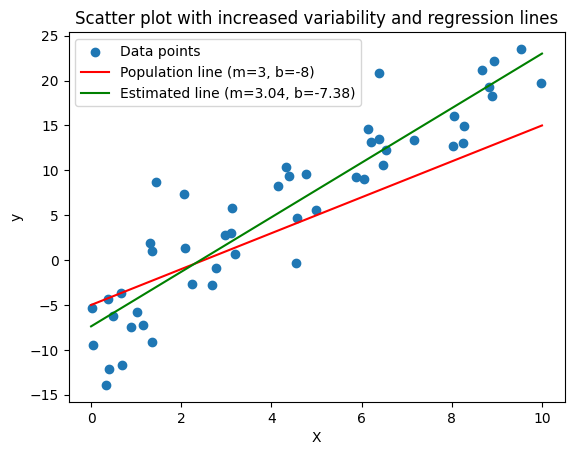

In [3]:
# Generate the data
x = 10 * np.random.rand(50)
y = 3 * x - 8 + np.random.randn(50) * 4

# Fit a linear regression model
x = x.reshape(-1, 1)
model = LinearRegression()
model.fit(x, y)

# Calculate the predicted values
y_pred = model.predict(x)

# Plot the scatter plot and regression lines
plt.scatter(x, y, label="Data points")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Scatter plot with increased variability and regression lines")

# Plot the actual population line
x_line = np.linspace(0, 10, 100)
y_actual = 2 * x_line - 5
plt.plot(x_line, y_actual, 'r', label="Population line (m=3, b=-8)")

# Plot the estimated regression line
y_estimated = model.coef_[0] * x_line + model.intercept_
plt.plot(x_line, y_estimated, 'g', label=f"Estimated line (m={model.coef_[0]:.2f}, b={model.intercept_:.2f})")

# Add legend and show the plot
plt.legend()
plt.show()


### implementing statistics

In [5]:
import pandas as pd
import statsmodels.api as sm

# Load the dataset
url = "https://raw.githubusercontent.com/justmarkham/scikit-learn-videos/master/data/Advertising.csv"
data = pd.read_csv(url, index_col=0)

# Define the independent variables (add a constant for the intercept)
X = data[['TV', 'Radio', 'Newspaper']]
X = sm.add_constant(X)

# Define the dependent variable
y = data['Sales']

# Fit the model using the independent and dependent variables
model = sm.OLS(y, X).fit()

# Print the summary of the model
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Thu, 21 May 2026   Prob (F-statistic):           1.58e-96
Time:                        11:30:30   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9389      0.312      9.422      0.0

### Degree of Freedom

In linear regression, the total degrees of freedom (df_total) represent the total number of data points minus 1. It represents the overall variability in the dataset that can be attributed to both the model and the residuals.

For a linear regression with n data points (observations), the total degrees of freedom can be calculated as:

- df_total = n − 1

where: n is the number of data points (observations) in the dataset

The total degrees of freedom in linear regression is divided into two components:

1. Degrees of freedom for the model (df_model): This is equal to the number of independent variables in the model (k).

2. Degrees of freedom for the residuals (df_residuals):
The degrees of freedom for the residuals indicate the number of independent pieces of information that are available for estimating the variability in the residuals (errors) after fitting the regression model.

- This is equal to the number of data points (n) minus the number of estimated parameters, including the intercept (k+1).

The sum of the degrees of freedom for the model and the degrees of freedom for the residuals is equal to the total degrees of freedom:

- df_total = df_model + df_residuals

### F-statistic & Prob(F-statistic)

The F-test for overall significance is a statistical test used to determine whether a linear regression model is statistically significant, meaning it provides a better fit to the data than just using the mean of the dependent variable.

Here are the steps involved in conducting an F-test for overall significance:

1. State the null and alternative hypotheses:
    - Null hypothesis (H0): All regression coefficients (except the intercept) are equal to zero (β1 = β2 = ... = βk = 0), meaning that none of the independent variables contribute significantly to the explanation of the dependent variable's variation.
    - Alternative hypothesis (H1): At least one regression coefficient is not equal to zero, indicating that at least one independent variable contributes significantly to the explanation of the dependent variable's variation.

2. Fit the linear regression model to the data, estimating the regression coefficients (intercept and slopes).

3. Calculate the Sum of Squares (SS) values:
    - Total Sum of Squares (TSS): The sum of squared differences between each observed value of the dependent variable and its mean.
    - Regression Sum of Squares (ESS): The sum of squared differences between the predicted values of the dependent variable and its mean.
    - Residual Sum of Squares (RSS): The sum of squared differences between the observed values and the predicted values of the dependent variable.

4. Compute the Mean Squares (MS) values:
    - Mean Square Regression (MSR): ESS divided by the degrees of freedom for the model (df_model), which is the number of independent variables (k).    This could also be called as Average Explained Variance per independent feature.
    - Mean Square Error (MSE): RSS divided by the degrees of freedom for the residuals (df_residuals), which is the number of data points (n) minus the number of estimated parameters, including the intercept (k+1). This could also be called as average unexplained variance per degree of freedom.

5. Calculate the F-statistic:
    - F-statistic= MSE / MSR
	​

6. Determine the p-value:
    - Compute the p-value associated with the calculated F-statistic using the F-distribution or a statistical software package.

7. Compare the calculated F-statistic to the p-value to the chosen significance level (α):
    - If the p-value < α, reject the null hypothesis. This indicates that at least one independent variable contributes significantly to the prediction of the dependent variable, and the overall regression model is statistically significant.
    - If the p-value ≥ α, fail to reject the null hypothesis. This suggests that none of the independent variables in the model contribute significantly to the prediction of the dependent variable, and the overall regression model is not statistically significant.

Following these steps, you can perform an F-test for overall significance in a linear regression analysis and determine whether the regression model is statistically significant.

### R2-Score

R-squared (R²), also known as the coefficient of determination, is a measure used in regression analysis to assess the goodness-of-fit of a model. It quantifies the proportion of the variance in the dependent variable (response variable) that can be explained by the independent variables (predictor variables) in the regression model. R-squared is a value between 0 and 1, with higher values indicating a better fit of the model to the observed data.

In the context of a simple linear regression, R² is calculated as the square of the correlation coefficient (r) between the observed and predicted values. In multiple regression, R² is obtained from the ratio of the explained sum of squares (ESS) to the total sum of squares (TSS):

R2 = TSS/ESS ; where:

- ESS (Explained Sum of Squares) is the sum of squared differences between the predicted values and the mean of the observed values. It represents the variation in the response variable that can be explained by the predictor variables in the model.
- TSS (Total Sum of Squares) is the sum of squared differences between the observed values and the mean of the observed values. It represents the total variation in the response variable.

An R-squared value of 0 indicates that the model does not explain any of the variance in the response variable, while an R-squared value of 1 indicates that the model explains all of the variance. However, R-squared can be misleading in some cases, especially when the number of predictor variables is large or when the predictor variables are not relevant to the response variable.


### Adjusted R-squared

Adjusted R-squared is a modified version of R-squared (R²) that adjusts for the number of predictor variables in a multiple regression model. It provides a more accurate measure of the goodness-of-fit of a model by considering the model's complexity.

In a multiple regression model, R-squared (R²) measures the proportion of variance in the response variable that is explained by the predictor variables. However, R-squared always increases or stays the same with the addition of new predictor variables, regardless of whether those variables contribute valuable information to the model. This can lead to overfitting, where a model becomes too complex and starts capturing noise in the data instead of the underlying relationships.

Adjusted R-squared accounts for the number of predictor variables in the model and the sample size, penalizing the model for adding unnecessary complexity. Adjusted R-squared can decrease when an irrelevant predictor variable is added to the model, making it a better metric for comparing models with different numbers of predictor variables.

The formula for adjusted R-squared is:

Adjusted R2 = 1 − [(1 − R^2) * (n-1)] / (n−k−1)
	​
where:

- R² is the R-squared of the model
- n is the number of observations in the dataset
- k is the number of predictor variables in the model

Bt using adjusted r-squared, you can more accurately assess the goodness-of-fit of a model and choose the optimal set of predictor variables for your analysis.

In [6]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Generate synthetic data
np.random.seed(42)
n = 100
x1 = np.random.normal(0, 1, n)
x2 = np.random.normal(0, 1, n)
irrelevant_predictors = np.random.normal(0, 1, (n, 10))

y = 2 * x1 + 3 * x2 + np.random.normal(0, 1, n)

# Helper function to calculate adjusted R-squared
def adjusted_r2(r2, n, k):
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)

# Fit linear regression models with different predictors
X = pd.DataFrame({'x1': x1, 'x2': x2})
X_with_irrelevant = pd.concat([X] + [pd.Series(irrelevant_predictors[:, i], name=f"irrelevant_{i}") for i in range(10)], axis=1)

model1 = LinearRegression().fit(X, y)
model2 = LinearRegression().fit(X_with_irrelevant, y)

# Calculate R-squared and adjusted R-squared for each model
models = [('Model with relevant predictors', model1, X.shape[1]), ('Model with irrelevant predictors', model2, X_with_irrelevant.shape[1])]

for name, model, k in models:
    r2 = r2_score(y, model.predict(X_with_irrelevant.iloc[:, :k]))
    adj_r2 = adjusted_r2(r2, n, k)
    print(f"{name}: R-squared = {r2:.3f}, Adjusted R-squared = {adj_r2:.3f}")


Model with relevant predictors: R-squared = 0.912, Adjusted R-squared = 0.910
Model with irrelevant predictors: R-squared = 0.919, Adjusted R-squared = 0.908


In [7]:
X

,x1,x2
0,0.496714,-1.415371
1,-0.138264,-0.420645
2,0.647689,-0.342715
3,1.523030,-0.802277
4,-0.234153,-0.161286
...,...,...
95,-1.463515,0.385317
96,0.296120,-0.883857
97,0.261055,0.153725
98,0.005113,0.058209


In [8]:
X_with_irrelevant

,x1,x2,irrelevant_0,irrelevant_1,irrelevant_2,irrelevant_3,irrelevant_4,irrelevant_5,irrelevant_6,irrelevant_7,irrelevant_8,irrelevant_9
0,0.496714,-1.415371,0.357787,0.560785,1.083051,1.053802,-1.377669,-0.937825,0.515035,0.513786,0.515048,3.852731
1,-0.138264,-0.420645,0.570891,1.135566,0.954002,0.651391,-0.315269,0.758969,-0.772825,-0.236819,-0.485364,0.081874
2,0.647689,-0.342715,2.314659,-1.867265,0.686260,-1.612716,-0.471932,1.088951,0.064280,-1.077745,-0.715304,0.679598
3,1.523030,-0.802277,-0.730367,0.216459,0.045572,-0.651600,2.143944,0.633919,-2.025143,0.186454,-0.661786,0.852433
4,-0.234153,-0.161286,-0.792521,-0.114736,0.504987,0.865755,-1.200296,-0.334501,-0.474945,-0.653329,1.765454,0.404982
...,...,...,...,...,...,...,...,...,...,...,...,...
95,-1.463515,0.385317,-0.991392,-2.153390,-0.638962,-1.323090,1.642015,1.009817,-0.688150,2.252436,0.981765,-0.324831
96,0.296120,-0.883857,-2.499406,2.290943,-1.389572,-1.645399,1.022570,2.439752,1.384273,0.563909,0.594754,0.853416
97,0.261055,0.153725,0.758929,0.281191,0.104201,-0.062593,-0.753965,-0.280675,-1.692957,-0.098340,-0.988591,-1.103589
98,0.005113,0.058209,0.179894,1.392002,0.918317,-1.570501,-0.989628,0.940771,-0.982487,-0.224633,0.550052,-0.968344


In [9]:
import pandas as pd

df = pd.DataFrame()

df['X'] = [2,3,5,5,7]
df['y'] = [2,4,3,5,5]

df

,X,y
0,2,2
1,3,4
2,5,3
3,5,5
4,7,5


In [10]:
import statsmodels.api as sm


# Add a constant to the independent variable
X = sm.add_constant(df['X'])

# Fit the linear regression model
model = sm.OLS(df['y'], X).fit()

# Print the summary of the model
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.530
Model:                            OLS   Adj. R-squared:                  0.373
Method:                 Least Squares   F-statistic:                     3.380
Date:                Thu, 21 May 2026   Prob (F-statistic):              0.163
Time:                        16:35:55   Log-Likelihood:                -5.9769
No. Observations:                   5   AIC:                             15.95
Df Residuals:                       3   BIC:                             15.17
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.6579      1.253      1.323      0.2

c:\Users\Vanilla\anaconda3\envs\myenv\lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
